In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
upload = files.upload()

# Get the first (and likely only) uploaded file name
if upload:
    uploaded_filename = list(upload.keys())[0]
    df = pd.read_csv(uploaded_filename)
    print(f"Successfully loaded '{uploaded_filename}' into a DataFrame.")
else:
    print("No file was uploaded.")

Saving heart.csv to heart.csv
Successfully loaded 'heart.csv' into a DataFrame.


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [4]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [5]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [6]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


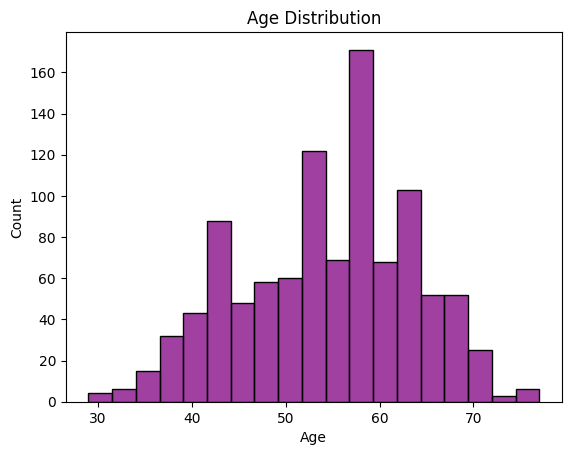

In [7]:
sns.histplot(df['age'], color = 'purple')
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

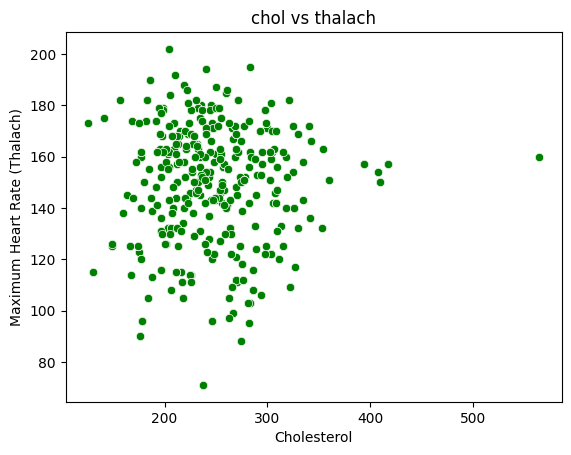

In [8]:
sns.scatterplot(x='chol', y='thalach', color='green', data=df)
plt.title("chol vs thalach")
plt.xlabel("Cholesterol")
plt.ylabel("Maximum Heart Rate (Thalach)")
plt.show()

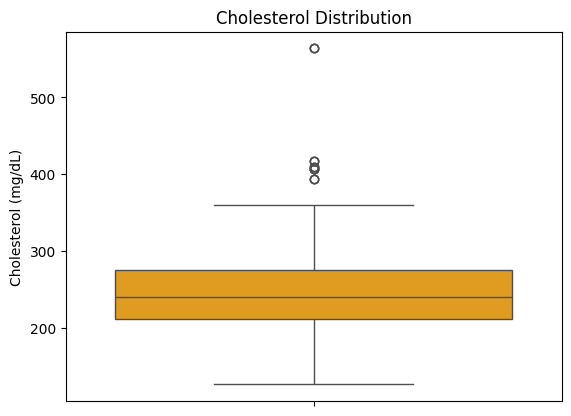

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.boxplot(y=df['chol'],color = 'orange')
plt.title("Cholesterol Distribution")
plt.ylabel("Cholesterol (mg/dL)")
plt.show()

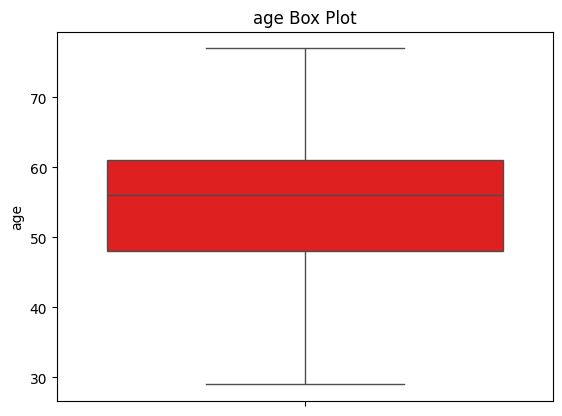

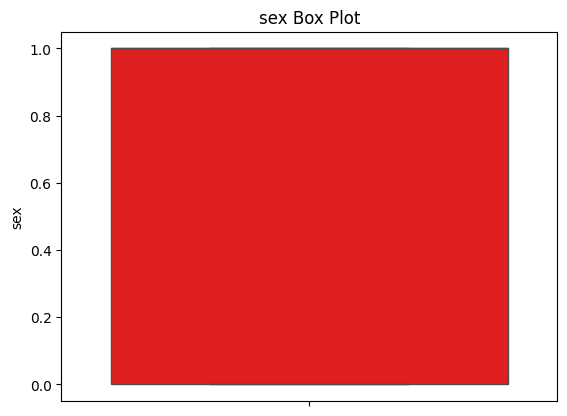

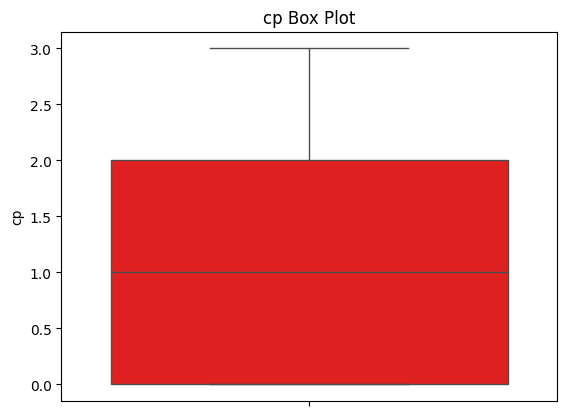

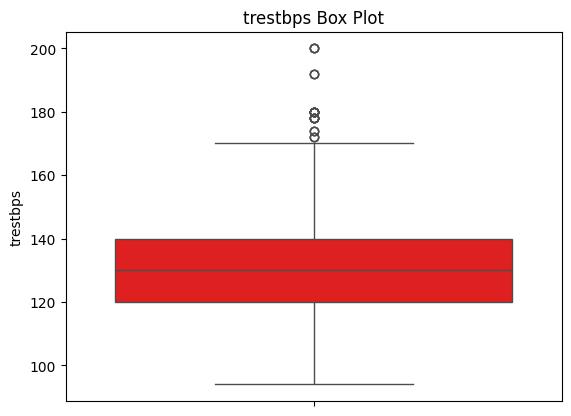

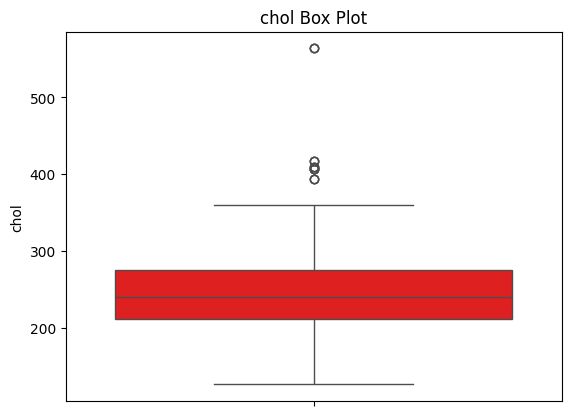

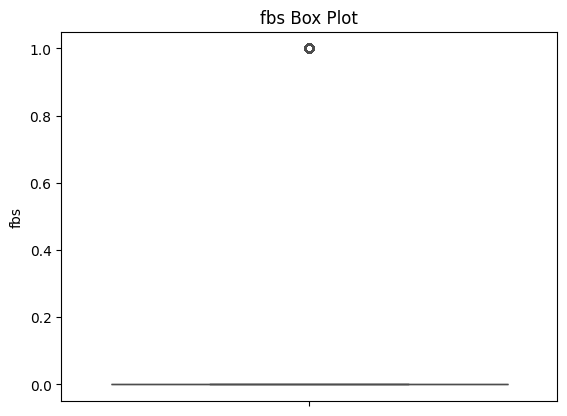

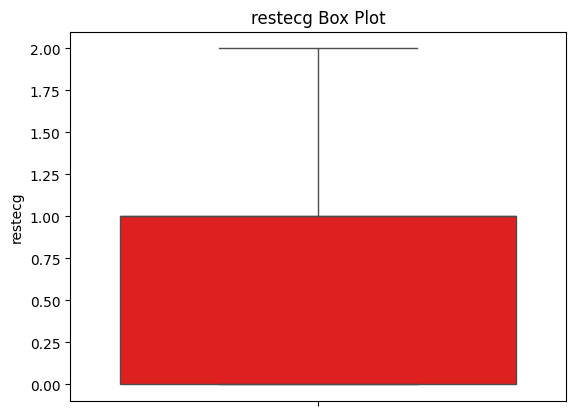

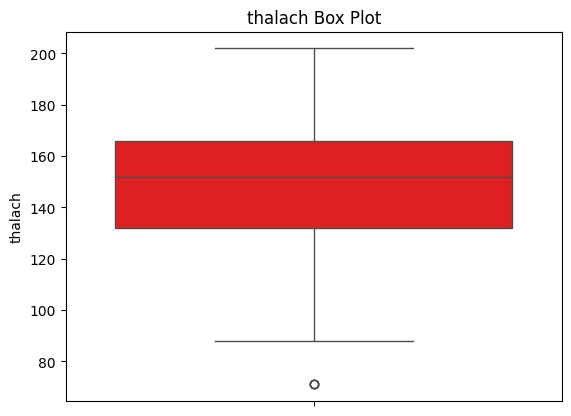

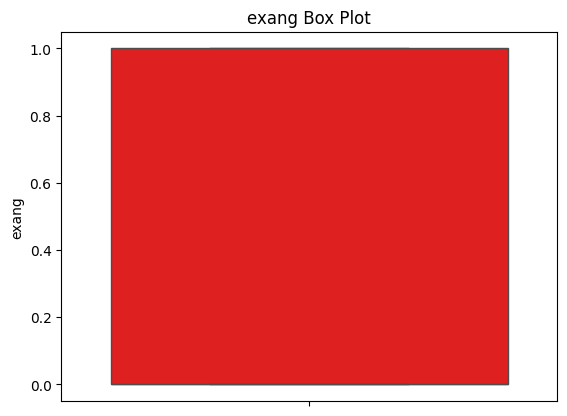

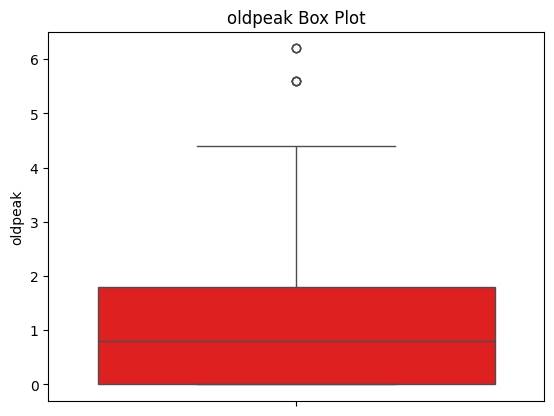

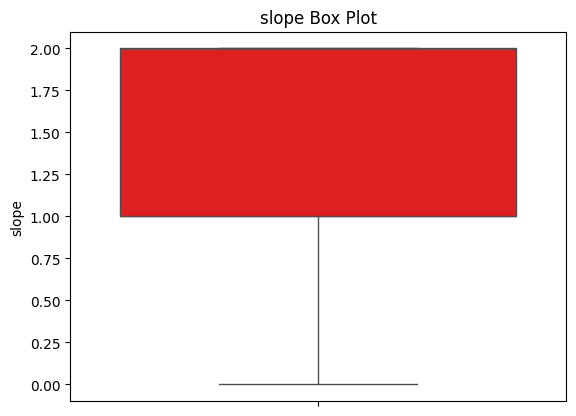

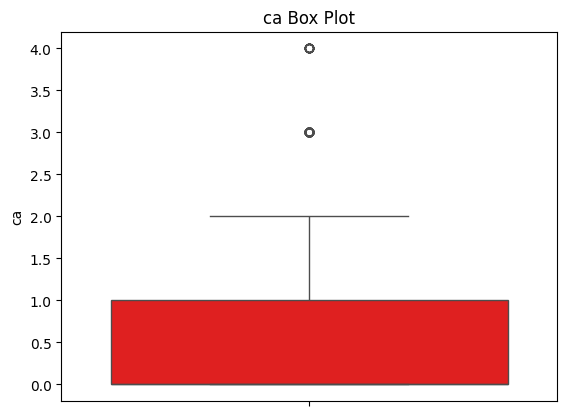

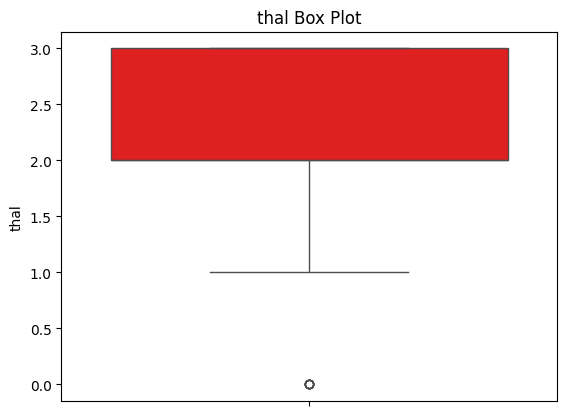

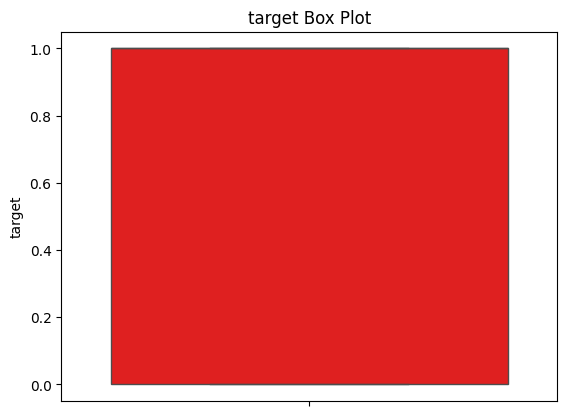

In [10]:
for col in df.columns:
  sns.boxplot(y=df[col],color = 'red')
  plt.title(f"{col} Box Plot")
  plt.show()

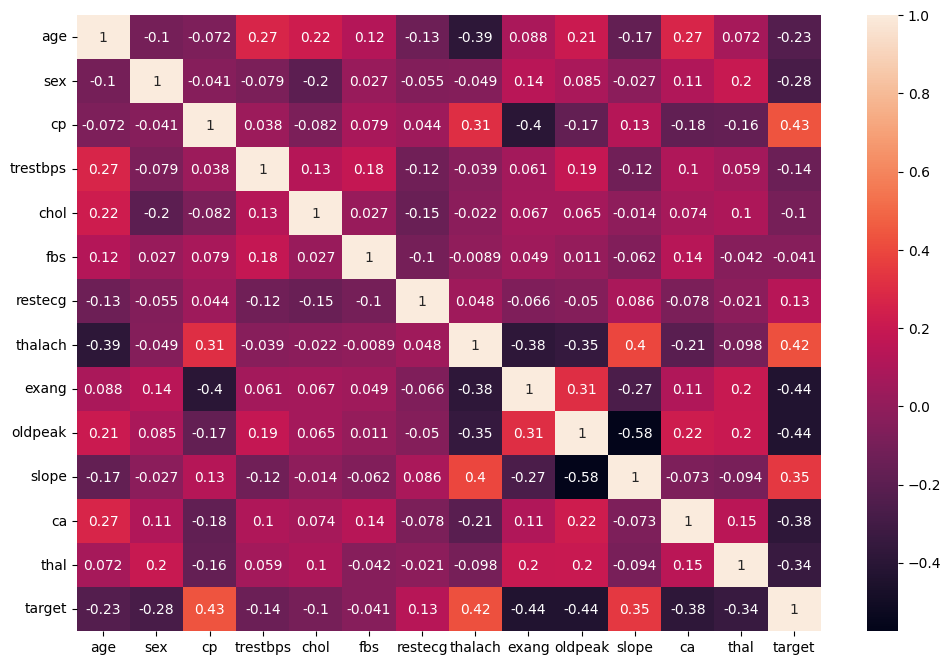

In [11]:
import matplotlib.pyplot as plt
fig = plt.figure(figsize=(12, 8))

sns.heatmap(df.corr(),annot=True)
plt.show()

In [12]:
x  = df.iloc[:,:-1]
y = -df.iloc[:,-1:]

In [13]:
#split into train and test
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=0)

In [14]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Instantiate the KNN model
knn = KNeighborsClassifier(n_neighbors=5) # You can adjust n_neighbors

# Train the model, converting y_train to a 1D array
knn.fit(x_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


KNeighborsClassifier()

In [17]:
# Make predictions on the test set
y_pred = knn.predict(x_test)
print(y_pred)

# Calculate and print the accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy of the KNN model: {accuracy:.4f}")

[-1  0  0 -1  0 -1  0 -1  0  0  0  0  0  0 -1 -1 -1  0 -1  0 -1  0 -1  0
 -1 -1 -1  0  0 -1 -1 -1 -1  0  0 -1 -1 -1 -1 -1  0 -1 -1 -1 -1  0 -1  0
  0  0  0 -1  0  0 -1  0 -1 -1  0  0  0  0 -1 -1  0  0  0 -1  0 -1 -1 -1
  0  0  0  0 -1 -1  0  0 -1  0 -1 -1 -1  0 -1  0  0  0  0  0 -1  0  0 -1
 -1  0 -1 -1 -1  0 -1  0  0 -1  0  0  0 -1  0 -1 -1  0  0 -1  0 -1  0  0
  0 -1 -1  0  0 -1 -1 -1 -1 -1  0  0 -1  0  0  0  0 -1  0 -1  0  0  0  0
 -1 -1 -1 -1 -1  0 -1 -1 -1  0  0  0  0 -1  0 -1  0 -1 -1  0 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1  0  0  0  0  0  0  0  0 -1 -1  0  0 -1
  0 -1  0 -1  0 -1  0  0 -1  0 -1  0 -1]
Accuracy of the KNN model: 0.7463


In [18]:
#cofusion matrics
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test,y_pred)
print(cm)
#

[[79 28]
 [24 74]]


In [20]:
#accuracy percantage
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)
accur = accuracy_score(y_test,y_pred)*100
print(f"Accuracy of the KNN model: {accur:.2f}%")


Accuracy of the KNN model: 74.63%


In [21]:
#classifier report
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))
#

              precision    recall  f1-score   support

          -1       0.77      0.74      0.75       107
           0       0.73      0.76      0.74        98

    accuracy                           0.75       205
   macro avg       0.75      0.75      0.75       205
weighted avg       0.75      0.75      0.75       205



In [22]:
#save the trained model
import pickle
pickle.dump(knn,open('model.pkl','wb'))

In [23]:
#predict wiith sample data
model = pickle.load(open('model.pkl','rb'))
print(model.predict([[63,1,3,145,233,1,0,150,0,2.3,0,0,1]]))

[-1]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
